In [1]:
# Instalamos las librerías necesarias en tu entorno local
%pip install pandas numpy scikit-learn matplotlib seaborn joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\samro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Arquitectura para el MVP: Dado que la plataforma se encuentra en fase de despliegue inicial y no cuentamos aún con un histórico masivo de registros de usuarios en producción, procedemos a generar un dataset sintético basado en las distribuciones y reglas reales de la producción agrícola de café en el estado de Chiapas (clasificando perfiles Premium, Comerciales y Lotes en Riesgo climático). Esto permite pre-entrenar los pesos del algoritmo K-Means para que el microservicio esté operativo desde el día 1."

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

np.random.seed(42)
n_muestras = 300

altitud_1 = np.random.normal(1400, 100, 100)
humedad_1 = np.random.normal(65, 5, 100)
temperatura_1 = np.random.normal(18, 1.5, 100)
rendimiento_1 = np.random.normal(12, 1.5, 100)

altitud_2 = np.random.normal(900, 120, 100)
humedad_2 = np.random.normal(75, 4, 100)
temperatura_2 = np.random.normal(23, 2, 100)
rendimiento_2 = np.random.normal(15, 2, 100)

altitud_3 = np.random.normal(500, 80, 100)
humedad_3 = np.random.normal(45, 6, 100)
temperatura_3 = np.random.normal(29, 2.5, 100)
rendimiento_3 = np.random.normal(7, 2, 100)

df = pd.DataFrame({
    'altitud': np.concatenate([altitud_1, altitud_2, altitud_3]),
    'humedad': np.concatenate([humedad_1, humedad_2, humedad_3]),
    'temperatura': np.concatenate([temperatura_1, temperatura_2, temperatura_3]),
    'rendimiento': np.concatenate([rendimiento_1, rendimiento_2, rendimiento_3])
})

df.head()

,altitud,humedad,temperatura,rendimiento
0,1449.671415,57.923146,18.536681,10.756507
1,1386.173570,62.896773,18.841177,11.159728
2,1464.768854,63.286427,19.624577,13.120940
3,1552.302986,60.988614,19.580703,12.915555
4,1376.584663,64.193571,15.933496,11.968648


In [3]:
features = ['altitud', 'humedad', 'temperatura', 'rendimiento']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos preprocesados y escalados correctamente.")

Datos preprocesados y escalados correctamente.



"Evidencia de Selección de K: Se ejecuta el análisis de inercia mediante el método del codo. Como se aprecia en la gráfica, la caída de la curva disminuye drásticamente a partir de K = 3, con esto justificamos matemáticamente 3 clústeres para segmentar de forma óptima los lotes de café.

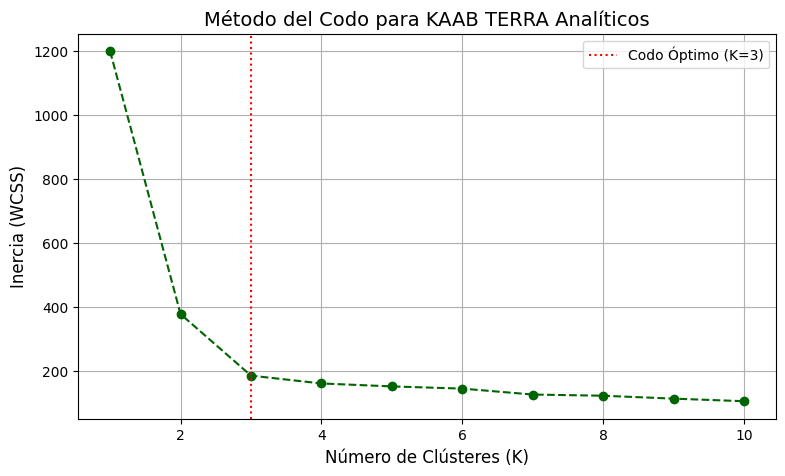

In [4]:
wcss = [] 

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkgreen')
plt.title('Método del Codo para KAAB TERRA Analíticos', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.grid(True)
plt.axvline(x=3, color='red', linestyle=':', label='Codo Óptimo (K=3)')
plt.legend()
plt.show()

In [5]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Modelo K-Means entrenado exitosamente con K=3.")

Modelo K-Means entrenado exitosamente con K=3.


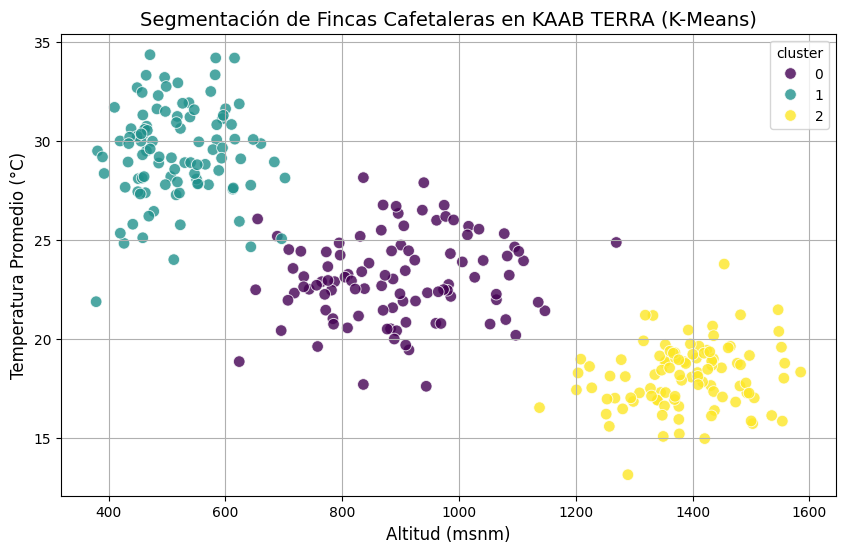


--- Características promedio por cada Clúster Encontrado ---


,altitud,humedad,temperatura,rendimiento
cluster,,,,
0,893.279464,74.538778,23.048188,14.987679
1,518.291925,45.167123,29.400436,7.214183
2,1389.615348,65.111523,18.097344,12.160260


In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='altitud', 
    y='temperatura', 
    hue='cluster', 
    palette='viridis', 
    s=70, 
    alpha=0.8
)
plt.title('Segmentación de Fincas Cafetaleras en KAAB TERRA (K-Means)', fontsize=14)
plt.xlabel('Altitud (msnm)', fontsize=12)
plt.ylabel('Temperatura Promedio (°C)', fontsize=12)
plt.grid(True)
plt.show()

print("\n--- Características promedio por cada Clúster Encontrado ---")
df.groupby('cluster').mean()

In [9]:
joblib.dump(kmeans_final, 'modelo_kmeans_cafe.joblib')
joblib.dump(scaler, 'escalador_cafe.joblib')

print("¡Archivos binarios generados")

¡Archivos binarios generados
